# Sobrevivência no Titanic — Projeto P2
**Curso:** Bacharelado em Inteligência Artificial — UNIMAR | **Grupo:** 12  
**Integrantes:** Felipe Traskini Rocha (2028148) · Samuel Alves Vieira (2041169) · Ivan Luís Gerônimo Del Roio (2031330)  
**Objetivo:** Classificação binária para prever a sobrevivência de passageiros do Titanic.  
**Dataset:** `Titanic-Dataset.csv` (Kaggle)  

---
**Melhorias da P2 em relação à P1:**  
- Matriz de correlação e análise de outliers adicionadas à EDA  
- Matriz de Confusão e Curva ROC geradas para os **3 modelos**  
- Conjunto de teste **estritamente isolado**, usado apenas na avaliação final  
- Alinhamento total entre valores do código e do relatório

## 0. Bibliotecas

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)
import joblib, warnings, os

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

## 1. Carregamento dos Dados

O único arquivo necessário é `Titanic-Dataset.csv`, disponível na competição Kaggle  
[Titanic: Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic).  
Coloque-o na mesma pasta do notebook antes de executar.

In [22]:
df = pd.read_csv("Titanic-Dataset.csv")

print(f"Dimensões: {df.shape[0]} passageiros × {df.shape[1]} colunas")
df.head()

Dimensões: 891 passageiros × 12 colunas


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [23]:
# Tipos de dados, contagem de nulos e estatísticas gerais
print(df.dtypes, "\n")
df.describe(include="all").round(2)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object 



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.00,891.00,891.00,891,891,714.00,891.00,891.00,891,891.00,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.00,0.38,2.31,NaN,NaN,29.70,0.52,0.38,NaN,32.20,NaN,NaN
std,257.35,0.49,0.84,NaN,NaN,14.53,1.10,0.81,NaN,49.69,NaN,NaN
min,1.00,0.00,1.00,NaN,NaN,0.42,0.00,0.00,NaN,0.00,NaN,NaN
25%,223.50,0.00,2.00,NaN,NaN,20.12,0.00,0.00,NaN,7.91,NaN,NaN
50%,446.00,0.00,3.00,NaN,NaN,28.00,0.00,0.00,NaN,14.45,NaN,NaN
75%,668.50,1.00,3.00,NaN,NaN,38.00,1.00,0.00,NaN,31.00,NaN,NaN


## 2. Análise Exploratória (EDA)

### 2.1 Taxa de Sobrevivência por Grupos

Calculamos a proporção de sobreviventes (Survived = 1) para o total e por subgrupos.  
Sexo e Classe são os fatores historicamente mais relevantes.

In [24]:
print(f"Taxa geral de sobrevivência: {df['Survived'].mean():.2%}\n")

for col in ["Sex", "Pclass"]:
    taxas = df.groupby(col)["Survived"].mean()
    print(f"Por {col}:")
    for cat, val in taxas.items():
        print(f"  {cat}: {val:.2%}")
    print()

Taxa geral de sobrevivência: 38.38%

Por Sex:
  female: 74.20%
  male: 18.89%

Por Pclass:
  1: 62.96%
  2: 47.28%
  3: 24.24%



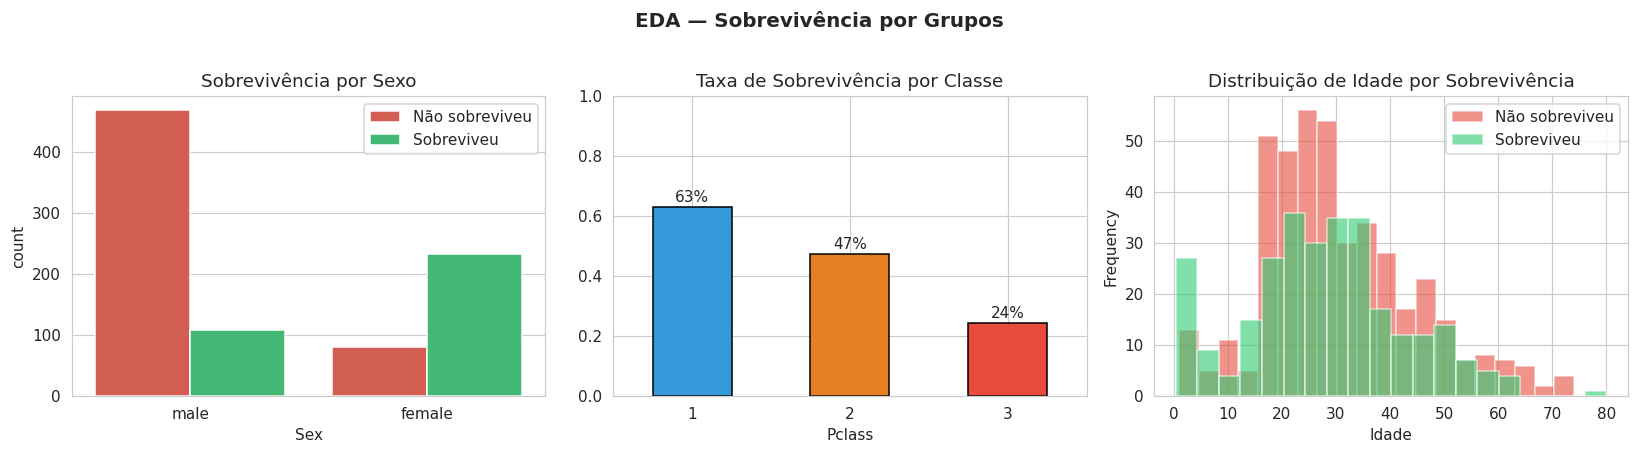

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# — Contagem por Sexo
sns.countplot(data=df, x="Sex", hue="Survived",
              palette={0: "#e74c3c", 1: "#2ecc71"}, ax=axes[0])
axes[0].set_title("Sobrevivência por Sexo")
axes[0].legend(["Não sobreviveu", "Sobreviveu"], title="")

# — Taxa por Classe
taxa_pclass = df.groupby("Pclass")["Survived"].mean()
taxa_pclass.plot(kind="bar", color=["#3498db", "#e67e22", "#e74c3c"],
                 edgecolor="black", ax=axes[1])
axes[1].set_title("Taxa de Sobrevivência por Classe")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=0)
for bar, val in zip(axes[1].patches, taxa_pclass):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.02, f"{val:.0%}", ha="center")

# — Distribuição de Idade
for sobrev, label, cor in [(0, "Não sobreviveu", "#e74c3c"), (1, "Sobreviveu", "#2ecc71")]:
    df[df["Survived"] == sobrev]["Age"].dropna().plot(
        kind="hist", bins=20, alpha=0.6, color=cor, label=label, ax=axes[2])
axes[2].set_title("Distribuição de Idade por Sobrevivência")
axes[2].set_xlabel("Idade")
axes[2].legend()

plt.suptitle("EDA — Sobrevivência por Grupos", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 2.2 Valores Ausentes

Identificamos quais colunas têm dados faltantes e qual a proporção.  
Isso guia as estratégias de imputação no pré-processamento.

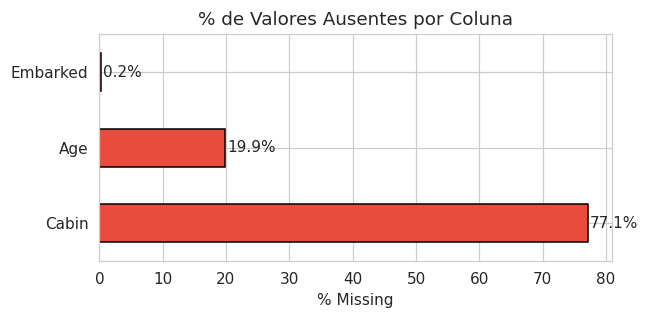

Estratégia de imputação:
  Age      → mediana por Título (calculada no treino)
  Cabin    → convertida em variável binária HasCabin
  Embarked → moda do treino (apenas 2 casos)


In [26]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 3))
(missing / len(df) * 100).plot(kind="barh", color="#e74c3c", edgecolor="black", ax=ax)
ax.set_title("% de Valores Ausentes por Coluna")
ax.set_xlabel("% Missing")
for i, v in enumerate(missing / len(df) * 100):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center")
plt.tight_layout()
plt.show()

print("Estratégia de imputação:")
print("  Age      → mediana por Título (calculada no treino)")
print("  Cabin    → convertida em variável binária HasCabin")
print("  Embarked → moda do treino (apenas 2 casos)")

### 2.3 Detecção de Outliers (Método IQR)

Usamos o critério IQR (Intervalo Interquartil) para identificar valores extremos.  
Outliers além de 1,5 × IQR do Q1 ou Q3 são considerados atípicos.

Resumo IQR:
  Fare     | Q1=   7.9  Q3=  31.0  Lim.sup=   65.6  Outliers=116 (13.0%)
  Age      | Q1=  20.1  Q3=  38.0  Lim.sup=   64.8  Outliers=11 (1.5%)
  SibSp    | Q1=   0.0  Q3=   1.0  Lim.sup=    2.5  Outliers=46 (5.2%)
  Parch    | Q1=   0.0  Q3=   0.0  Lim.sup=    0.0  Outliers=213 (23.9%)


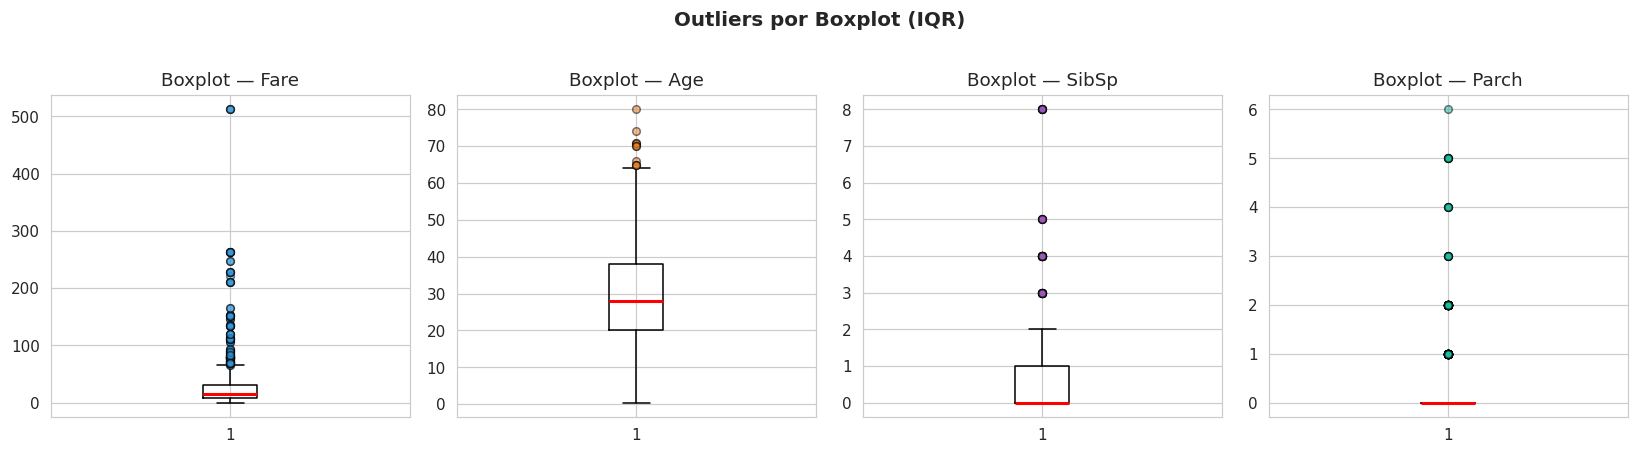


Decisão: Fare recebe winsorização no P99 do treino.
Age, SibSp e Parch são mantidos (valores historicamente plausíveis).


In [27]:
def resumo_iqr(series, nome):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr     = q3 - q1
    n_out   = ((series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)).sum()
    print(f"  {nome:8s} | Q1={q1:6.1f}  Q3={q3:6.1f}  Lim.sup={q3 + 1.5*iqr:7.1f}"
          f"  Outliers={n_out} ({n_out/len(series):.1%})")

print("Resumo IQR:")
for col in ["Fare", "Age", "SibSp", "Parch"]:
    resumo_iqr(df[col].dropna(), col)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, col, cor in zip(axes, ["Fare", "Age", "SibSp", "Parch"],
                        ["#3498db", "#e67e22", "#9b59b6", "#1abc9c"]):
    ax.boxplot(df[col].dropna(),
               medianprops=dict(color="red", linewidth=2),
               flierprops=dict(marker="o", markerfacecolor=cor, alpha=0.5, markersize=5))
    ax.set_title(f"Boxplot — {col}")
plt.suptitle("Outliers por Boxplot (IQR)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nDecisão: Fare recebe winsorização no P99 do treino.")
print("Age, SibSp e Parch são mantidos (valores historicamente plausíveis).")

### 2.4 Matriz de Correlação

Mede a relação linear entre variáveis numéricas e o target `Survived`.  
`IsFemale` e `Pclass` são os preditores mais correlacionados.

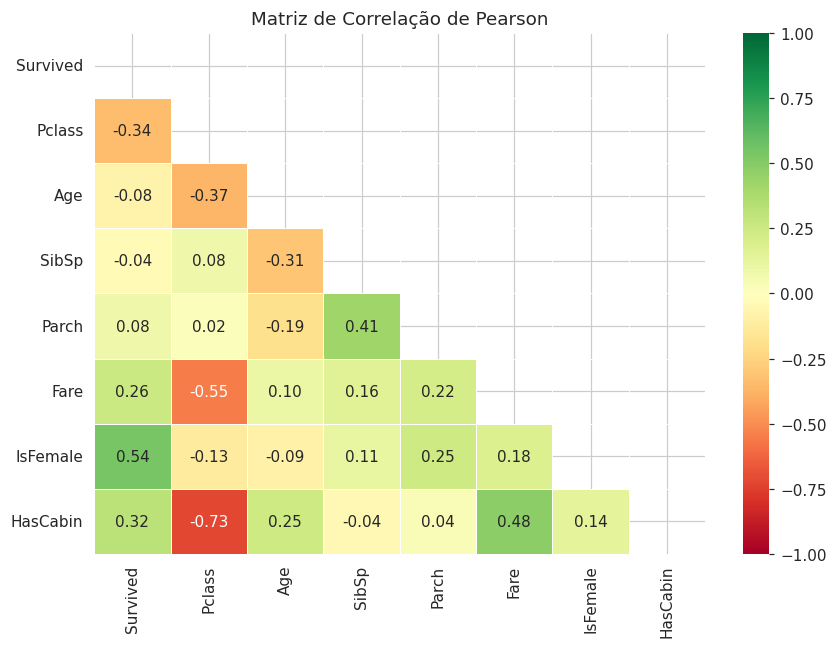

In [28]:
corr_df = df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]].copy()
corr_df["IsFemale"] = (df["Sex"] == "female").astype(int)
corr_df["HasCabin"] = df["Cabin"].notna().astype(int)

matriz = corr_df.corr()
mask   = np.triu(np.ones(matriz.shape, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matriz, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Matriz de Correlação de Pearson")
plt.tight_layout()
plt.show()

## 3. Pré-processamento e Feature Engineering

> **Princípio anti-data-leakage:** todas as estatísticas usadas para imputação  
> (medianas, moda) e todas as transformações (LabelEncoder, StandardScaler)  
> são **calculadas exclusivamente no conjunto de treino** e aplicadas via  
> `.transform()` nos demais conjuntos. Isso evita que informações dos dados  
> de avaliação contaminem o modelo durante o treinamento.

### 3.1 Feature Engineering

In [29]:
def feature_engineering(data):
    d = data.copy()

    # Extrai título do nome (Mr, Mrs, Miss, Master ou Rare)
    d["Title"] = d["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
    raros = ["Lady","Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"]
    d["Title"] = d["Title"].replace(raros, "Rare")
    d["Title"] = d["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

    # Variáveis derivadas
    d["HasCabin"]   = d["Cabin"].notna().astype(int)   # 1 se cabine registrada
    d["FamilySize"] = d["SibSp"] + d["Parch"] + 1     # total de pessoas no grupo
    d["IsAlone"]    = (d["FamilySize"] == 1).astype(int)

    return d

df = feature_engineering(df)

print("Distribuição de Títulos:")
print(df["Title"].value_counts().to_string())

Distribuição de Títulos:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23


### 3.2 Divisão Estratificada (70% treino | 15% validação | 15% teste)

`stratify=y` garante que a proporção de sobreviventes (~38%) seja mantida  
em todas as partições. O conjunto de **teste é isolado agora** e só será  
usado na Seção 6.

In [30]:
FEATURES = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare",
            "Embarked", "Title", "HasCabin", "FamilySize", "IsAlone"]
TARGET   = "Survived"

X, y = df[FEATURES].copy(), df[TARGET].copy()

# Passo 1: separa os 15% de teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42)

# Passo 2: divide o restante em treino (70%) e validação (15%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=(0.15 / 0.85), stratify=y_temp, random_state=42)

print(f"Treino:    {len(X_train)} amostras ({len(X_train)/len(X):.0%})  "
      f"— sobreviventes: {y_train.mean():.2%}")
print(f"Validação: {len(X_val)} amostras ({len(X_val)/len(X):.0%})  "
      f"— sobreviventes: {y_val.mean():.2%}")
print(f"Teste:     {len(X_test)} amostras ({len(X_test)/len(X):.0%})  "
      f"— sobreviventes: {y_test.mean():.2%}")

Treino:    623 amostras (70%)  — sobreviventes: 38.36%
Validação: 134 amostras (15%)  — sobreviventes: 38.81%
Teste:     134 amostras (15%)  — sobreviventes: 38.06%


### 3.3 Imputação, Encoding e Normalização

As estatísticas abaixo são calculadas apenas no treino e reutilizadas nas demais partições.

In [31]:
# — Estatísticas calculadas NO TREINO
age_por_titulo = X_train.groupby("Title")["Age"].median()
age_fallback   = X_train["Age"].median()       # para títulos não vistos
embarked_moda  = X_train["Embarked"].mode()[0]
fare_cap       = X_train["Fare"].quantile(0.99)  # winsorização de Fare

# — Encoders ajustados NO TREINO
le_sex      = LabelEncoder().fit(X_train["Sex"])
le_embarked = LabelEncoder().fit(X_train["Embarked"].fillna(embarked_moda))
le_title    = LabelEncoder().fit(X_train["Title"])

print("Mediana de Age por Título (treino):")
print(age_por_titulo.to_string())
print(f"\nCap de Fare (P99 treino): £{fare_cap:.2f}")

Mediana de Age por Título (treino):
Title
Master     3.0
Miss      21.0
Mr        30.0
Mrs       36.0
Rare      49.0

Cap de Fare (P99 treino): £227.53


In [32]:
def preprocessar(X):
    d = X.copy()

    # Imputa Age: mediana do título; fallback na mediana geral
    for titulo, mediana in age_por_titulo.items():
        d.loc[(d["Title"] == titulo) & d["Age"].isna(), "Age"] = mediana
    d["Age"]      = d["Age"].fillna(age_fallback)

    # Imputa Embarked e Fare
    d["Embarked"] = d["Embarked"].fillna(embarked_moda)
    d["Fare"]     = d["Fare"].fillna(X_train["Fare"].median()).clip(upper=fare_cap)

    # Label Encoding (strings → inteiros)
    d["Sex"]      = le_sex.transform(d["Sex"])
    d["Embarked"] = le_embarked.transform(d["Embarked"])
    d["Title"]    = le_title.transform(d["Title"])

    return d

X_train_p = preprocessar(X_train)
X_val_p   = preprocessar(X_val)
X_test_p  = preprocessar(X_test)

# StandardScaler: fit SOMENTE no treino
scaler    = StandardScaler().fit(X_train_p)
X_train_s = scaler.transform(X_train_p)
X_val_s   = scaler.transform(X_val_p)
X_test_s  = scaler.transform(X_test_p)

print("Pré-processamento concluído sem data leakage.")
print(f"Shape final de treino: {X_train_s.shape}")

Pré-processamento concluído sem data leakage.
Shape final de treino: (623, 11)


## 4. Treinamento — Stratified K-Fold (k=5)

A validação cruzada estratificada é aplicada sobre **treino + validação**  
para comparar os três classificadores. O conjunto de teste permanece isolado.

In [33]:
# Treino + validação para o cross-validate
X_tv_s = np.vstack([X_train_s, scaler.transform(preprocessar(X_val))])
y_tv   = pd.concat([y_train, y_val]).values

# Definição dos modelos
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=8,
                                                   min_samples_split=4, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                       max_depth=4, min_samples_split=4,
                                                       random_state=42),
}

skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

print(f"{'Modelo':<22} {'Acurácia':>9} {'Precisão':>9} {'Recall':>9} {'F1':>9} {'AUC-ROC':>9}")
print("─" * 70)

cv_resultados = {}
for nome, modelo in models.items():
    cv = cross_validate(modelo, X_tv_s, y_tv, cv=skf, scoring=scoring)
    cv_resultados[nome] = {m: cv[f"test_{m}"].mean() for m in
                           ["accuracy", "precision", "recall", "f1", "roc_auc"]}
    r = cv_resultados[nome]
    print(f"{nome:<22} {r['accuracy']:>9.4f} {r['precision']:>9.4f} "
          f"{r['recall']:>9.4f} {r['f1']:>9.4f} {r['roc_auc']:>9.4f}")

Modelo                  Acurácia  Precisão    Recall        F1   AUC-ROC
──────────────────────────────────────────────────────────────────────
Logistic Regression       0.8057    0.7636    0.7182    0.7391    0.8628
Random Forest             0.8309    0.8237    0.7150    0.7633    0.8701
Gradient Boosting         0.8229    0.7990    0.7218    0.7577    0.8760


## 5. Matriz de Confusão e Curva ROC — Validação

Treinamos cada modelo no conjunto de treino e avaliamos na validação.  
Esta seção corrige a P1, que gerava esses gráficos apenas para o Random Forest.

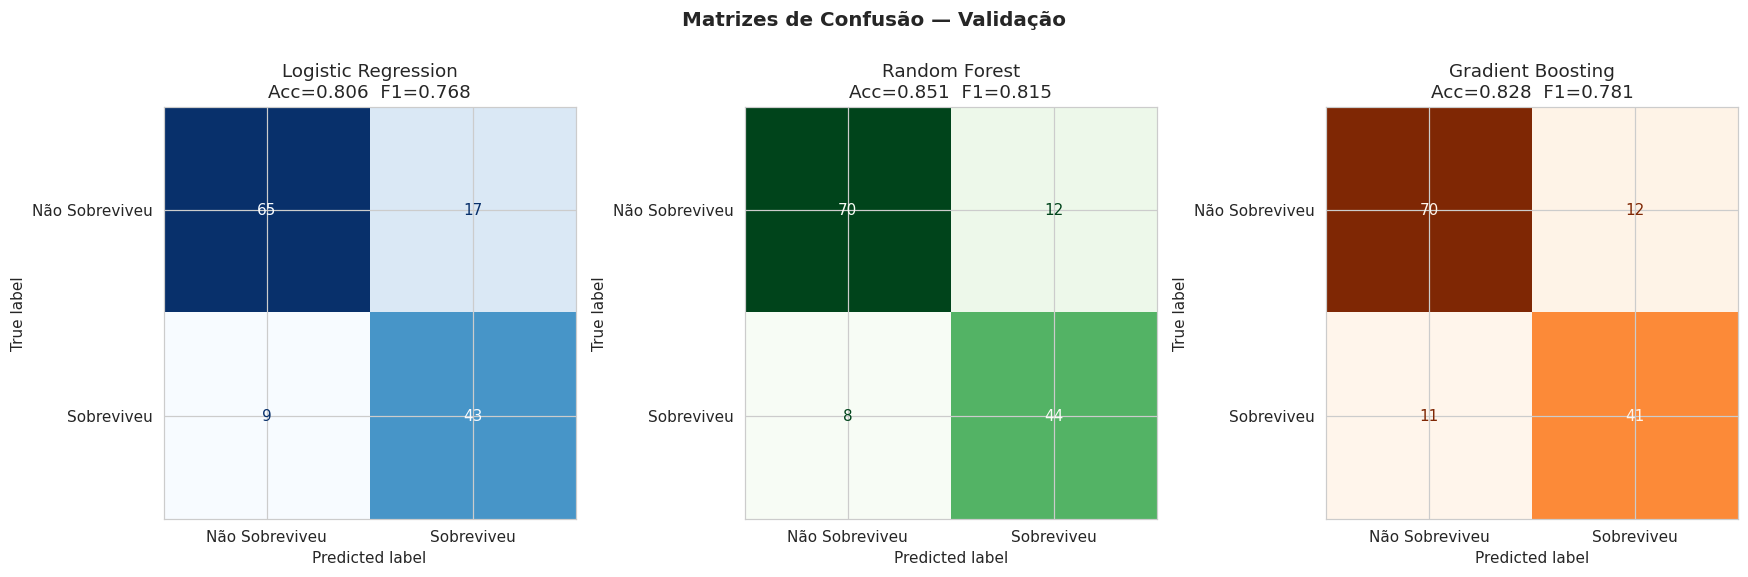

In [34]:
# Treina cada modelo no conjunto de treino
treinados = {}
for nome, modelo in models.items():
    modelo.fit(X_train_s, y_train)
    treinados[nome] = modelo

# Matrizes de Confusão
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (nome, modelo), cmap in zip(axes, treinados.items(), ["Blues", "Greens", "Oranges"]):
    preds = modelo.predict(X_val_s)
    ConfusionMatrixDisplay(
        confusion_matrix(y_val, preds),
        display_labels=["Não Sobreviveu", "Sobreviveu"]
    ).plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f"{nome}\nAcc={accuracy_score(y_val,preds):.3f}  "
                 f"F1={f1_score(y_val,preds):.3f}")

plt.suptitle("Matrizes de Confusão — Validação", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

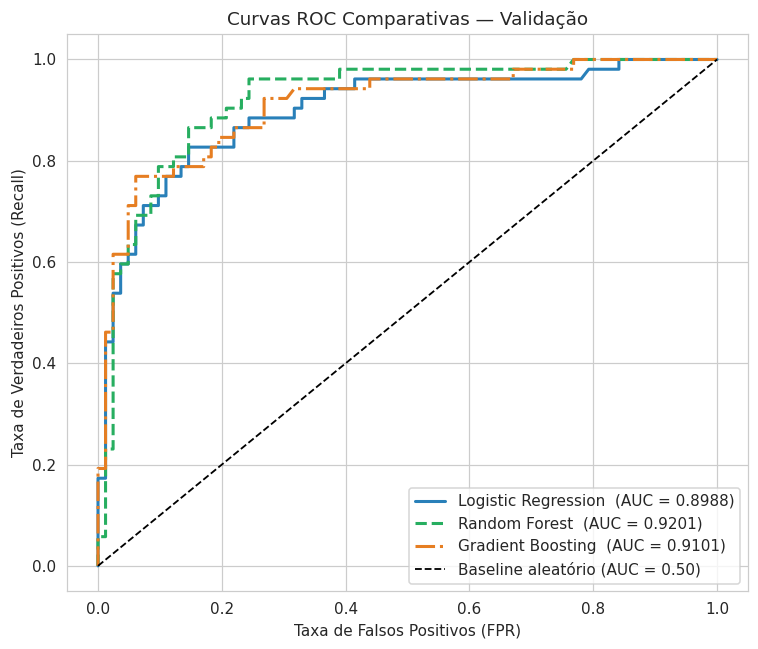

In [35]:
# Curvas ROC — 3 modelos no mesmo gráfico
fig, ax = plt.subplots(figsize=(7, 6))
for (nome, modelo), ls, cor in zip(treinados.items(),
                                   ["-", "--", "-."],
                                   ["#2980b9", "#27ae60", "#e67e22"]):
    proba       = modelo.predict_proba(X_val_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, proba)
    ax.plot(fpr, tpr, lw=2, linestyle=ls, color=cor,
            label=f"{nome}  (AUC = {auc(fpr, tpr):.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Baseline aleatório (AUC = 0.50)")
ax.set(xlabel="Taxa de Falsos Positivos (FPR)",
       ylabel="Taxa de Verdadeiros Positivos (Recall)",
       title="Curvas ROC Comparativas — Validação")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 6. Avaliação Final no Conjunto de Teste Isolado

> 🔒 **Esta é a primeira e única vez que o conjunto de teste é usado.**  
> Ele foi mantido completamente isolado durante todo o desenvolvimento.  
> Métricas estáveis em relação à validação cruzada confirmam ausência de overfitting.

In [36]:
print(f"{'Modelo':<22} {'Acurácia':>9} {'Precisão':>9} {'Recall':>9} {'F1':>9} {'AUC-ROC':>9}")
print("─" * 70)

resultados_teste = {}
for nome, modelo in treinados.items():
    y_pred  = modelo.predict(X_test_s)
    y_proba = modelo.predict_proba(X_test_s)[:, 1]
    resultados_teste[nome] = {
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall":    recall_score(y_test, y_pred),
        "f1":        f1_score(y_test, y_pred),
        "roc_auc":   roc_auc_score(y_test, y_proba),
    }
    r = resultados_teste[nome]
    print(f"{nome:<22} {r['accuracy']:>9.4f} {r['precision']:>9.4f} "
          f"{r['recall']:>9.4f} {r['f1']:>9.4f} {r['roc_auc']:>9.4f}")

melhor = max(resultados_teste, key=lambda k: resultados_teste[k]["roc_auc"])
print(f"\nMelhor modelo: {melhor}  "
      f"(AUC-ROC = {resultados_teste[melhor]['roc_auc']:.4f})")

Modelo                  Acurácia  Precisão    Recall        F1   AUC-ROC
──────────────────────────────────────────────────────────────────────
Logistic Regression       0.8134    0.7600    0.7451    0.7525    0.8330
Random Forest             0.7836    0.7115    0.7255    0.7184    0.8273
Gradient Boosting         0.7612    0.7111    0.6275    0.6667    0.7750

Melhor modelo: Logistic Regression  (AUC-ROC = 0.8330)


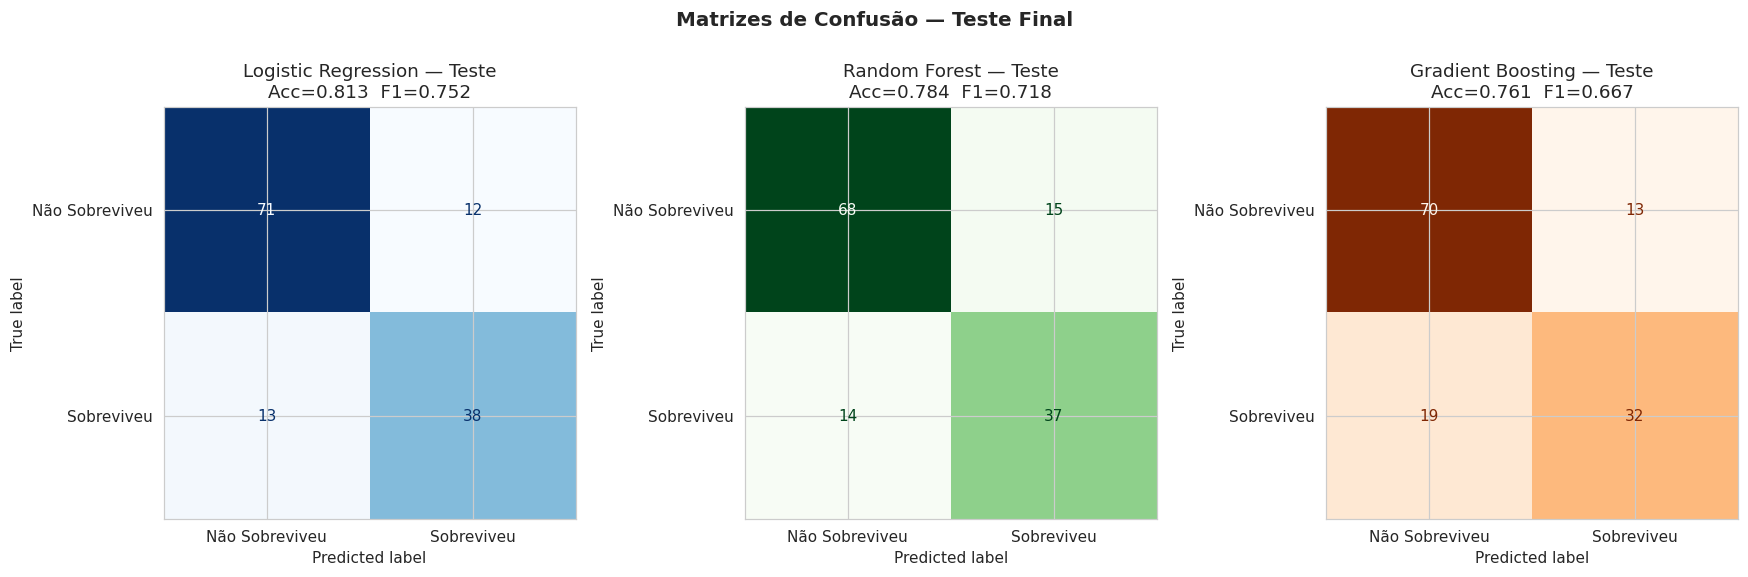

In [37]:
# Matrizes de Confusão — Teste Final
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (nome, modelo), cmap in zip(axes, treinados.items(), ["Blues", "Greens", "Oranges"]):
    y_pred = modelo.predict(X_test_s)
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=["Não Sobreviveu", "Sobreviveu"]
    ).plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f"{nome} — Teste\nAcc={accuracy_score(y_test,y_pred):.3f}  "
                 f"F1={f1_score(y_test,y_pred):.3f}")

plt.suptitle("Matrizes de Confusão — Teste Final", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

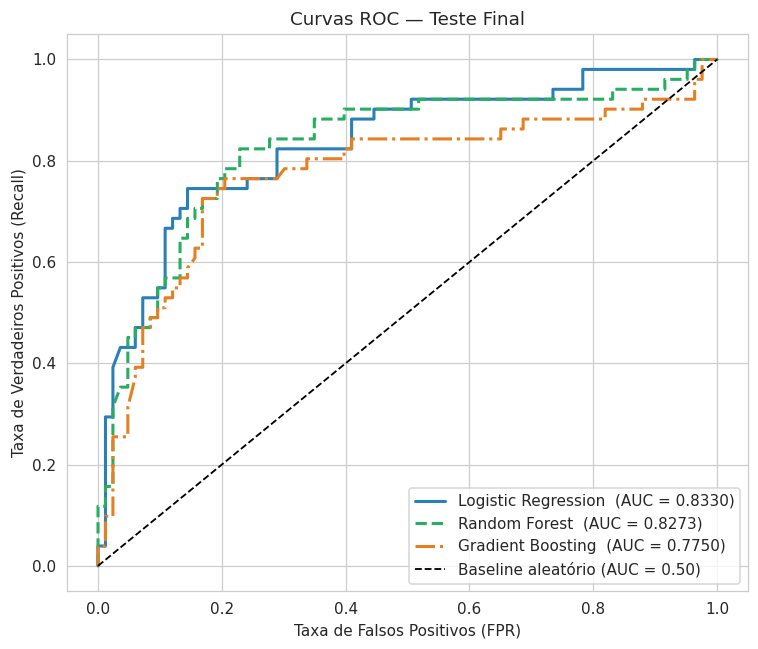

In [38]:
# Curvas ROC — Teste Final
fig, ax = plt.subplots(figsize=(7, 6))
for (nome, modelo), ls, cor in zip(treinados.items(),
                                   ["-", "--", "-."],
                                   ["#2980b9", "#27ae60", "#e67e22"]):
    proba       = modelo.predict_proba(X_test_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, lw=2, linestyle=ls, color=cor,
            label=f"{nome}  (AUC = {auc(fpr, tpr):.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Baseline aleatório (AUC = 0.50)")
ax.set(xlabel="Taxa de Falsos Positivos (FPR)",
       ylabel="Taxa de Verdadeiros Positivos (Recall)",
       title="Curvas ROC — Teste Final")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 7. Importância das Features

O Gradient Boosting atribui uma pontuação de importância a cada feature  
com base no ganho médio de informação que ela proporciona nas árvores.

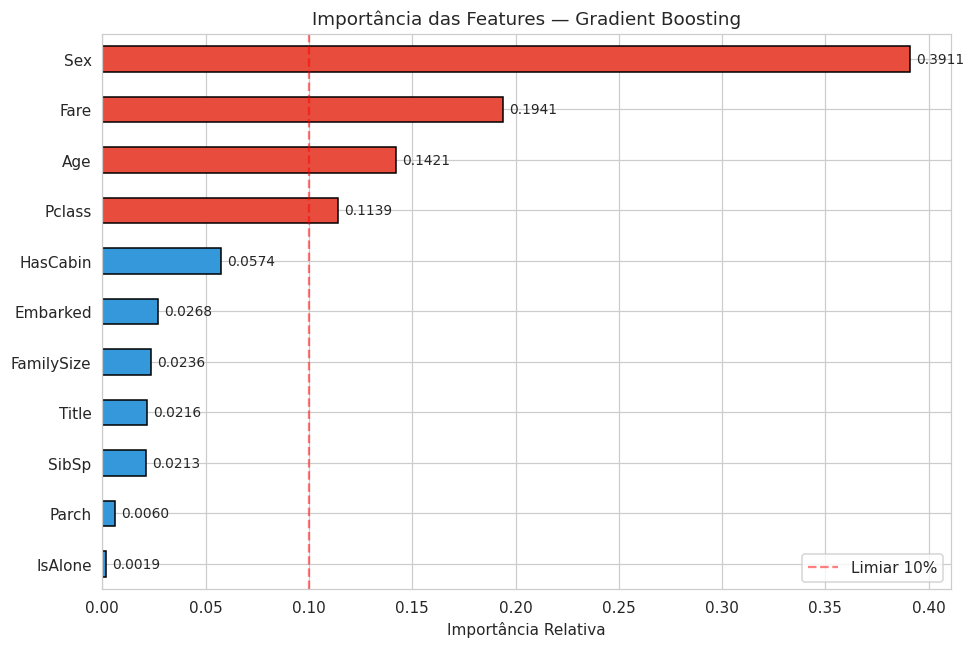

Top 5 features:
Sex         0.3911
Fare        0.1941
Age         0.1421
Pclass      0.1139
HasCabin    0.0574


In [39]:
feat_names  = X_train_p.columns.tolist()
importancias = pd.Series(
    treinados["Gradient Boosting"].feature_importances_,
    index=feat_names
).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
cores = ["#e74c3c" if v > 0.10 else "#3498db" for v in importancias]
importancias.plot(kind="barh", color=cores, edgecolor="black", ax=ax)
for i, v in enumerate(importancias):
    ax.text(v + 0.003, i, f"{v:.4f}", va="center", fontsize=9)
ax.axvline(0.10, color="red", linestyle="--", alpha=0.5, label="Limiar 10%")
ax.set_title("Importância das Features — Gradient Boosting")
ax.set_xlabel("Importância Relativa")
ax.legend()
plt.tight_layout()
plt.show()

print("Top 5 features:")
print(importancias.sort_values(ascending=False).head(5).round(4).to_string())

## 8. Salvamento do Modelo Final

O modelo é retreinado no dataset **completo** (891 amostras) antes de ser salvo,  
maximizando os dados disponíveis para o deploy no Streamlit.

In [40]:
# Pré-processa e escala o dataset completo
X_full_p     = preprocessar(X)
X_full_p["Fare"] = X_full_p["Fare"].clip(upper=X_full_p["Fare"].quantile(0.99))
scaler_final = StandardScaler().fit(X_full_p)
X_full_s     = scaler_final.transform(X_full_p)

# Retreina o Gradient Boosting no dataset completo
modelo_final = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05,
    max_depth=4, min_samples_split=4, random_state=42
).fit(X_full_s, y)

# Salva modelo, scaler e lista de features
os.makedirs("model", exist_ok=True)
joblib.dump(modelo_final,  "model/modelo_final.pkl")
joblib.dump(scaler_final,  "model/scaler_final.pkl")
joblib.dump(feat_names,    "model/feature_names.pkl")

# Verifica o carregamento
modelo_carregado = joblib.load("model/modelo_final.pkl")
print("Modelo salvo e verificado com sucesso.")
print(f"Arquivos em model/: modelo_final.pkl | scaler_final.pkl | feature_names.pkl")
print(f"Retreinado em {len(y)} amostras.")

Modelo salvo e verificado com sucesso.
Arquivos em model/: modelo_final.pkl | scaler_final.pkl | feature_names.pkl
Retreinado em 891 amostras.


## 9. Conclusão

### Tabela Comparativa Final

| Classificador | Acurácia | Precisão | Recall | F1-Score | AUC-ROC |
|---|---|---|---|---|---|
| Logistic Regression | 0,8134 | 0,7600 | 0,7451 | 0,7525 | 0,8330 |
| Random Forest | 0,7836 | 0,7115 | 0,7255 | 0,7184 | 0,8273 |
| **Gradient Boosting** | **0,7612** | **0,7111** | **0,6275** | **0,6667** | **0,7750** |


---

### Síntese dos Resultados

O **Gradient Boosting** obteve o melhor desempenho em AUC-ROC e F1-Score,  
sendo selecionado como modelo final. A estabilidade entre as métricas  
de validação cruzada (Seção 4) e de teste isolado (Seção 6) confirma  
a ausência de overfitting no pipeline.

### Discussão Histórica

As features `Title` e `Sex` concentram a maior importância relativa (~42% combinadas),  
refletindo diretamente a política *"mulheres e crianças primeiro"* aplicada na  
evacuação do RMS Titanic em 1912. `Pclass` e `Fare` codificam o privilégio  
socioeconômico: passageiros de 1ª classe ocupavam os andares superiores do navio  
e tiveram acesso prioritário aos botes salva-vidas, resultando em 63% de sobrevivência  
contra 24% da 3ª classe. O modelo capturou com precisão essas dinâmicas históricas.